<a href="https://colab.research.google.com/github/thimeshaA/Crystallization_Forecasting-Modal/blob/main/Crystallization_Forecasting_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Salt Crystallization Forecasting Model
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USERNAME/REPOSITORY/blob/main/Crystallization_Forecasting_Final.ipynb)

**Hybrid LSTM + Calibrated Production Formula**

| | |
|---|---|
| **Parameter forecast** | LSTM → next 60 days daily (8 crystallization params) |
| **Monthly production** | Calibrated formula → next 2 months |
| **Seasonal production** | Same formula → current season + next season |
| **ONNX export** | `crystallization_model.onnx` for TS/non-Python ML service |
| **Production constants** | `calibration_constants.json` for TS service |
| **Scaler constants** | `scaler_constants.json` for TS service (normalize input before ONNX) |

### ONNX Input Shapes (for ML service)
| Input | Shape | Description |
|---|---|---|
| `log_input` | `(1, 60, 8)` | Last 60 days of 8 crystallization parameters |
| `weather_input` | `(1, 60, 14)` | Last 60 days of 14 weather columns |

### ONNX Output Shape
| Output | Shape | Reshape to |
|---|---|---|
| `output` | `(1, 480)` | `(60, 8)` → 60 days × 8 parameters |

### Production Formula (in TS service)
```
monthly_production = (num_salt_beds × beds_coef)
                   + (monthly_rain_sum × rain_coef)
                   + (monthly_temp_mean × temp_coef)
                   + intercept
```
All coefficients in `calibration_constants.json`.

---
## Cell 1 — Install Packages

In [ ]:
!pip install pmdarima openpyxl tensorflow pandas numpy scikit-learn matplotlib tf2onnx onnx -q
print('✓ All packages installed')

✓ All packages installed


---
## Cell 2 — Imports

In [ ]:
import pandas as pd
import numpy as np
import json
import pickle
import joblib
import os
import re
import tensorflow as tf
from datetime import datetime, timedelta
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, BatchNormalization,
                                      Input, Bidirectional, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('✓ All imports successful')

---
## Cell 3 — User Inputs
**Edit these before running.**

In [27]:
# ============================================================
# USER INPUTS — EDIT THESE
# ============================================================
current_date  = '2025-05-01'
num_salt_beds = 8000

production_history = [
    {'month': '2024-11-01', 'production_volume': 20753.8},
    {'month': '2024-12-01', 'production_volume': 22546.6},
    {'month': '2025-01-01', 'production_volume':   759.8},
    {'month': '2025-02-01', 'production_volume': 24729.8},
    {'month': '2025-03-01', 'production_volume': 16971.2},
    {'month': '2025-04-01', 'production_volume': 41072.6},
]

print('=' * 60)
print('USER INPUTS')
print('=' * 60)
print(f'  Forecast start date : {current_date}')
print(f'  Active salt beds    : {num_salt_beds:,}')
print('=' * 60)

USER INPUTS
  Forecast start date : 2025-05-01
  Active salt beds    : 8,000


---
## Cell 4 — Helper Functions

In [ ]:
# Season boundaries
YALA_MONTHS = [5, 6, 7, 8]          # May–Aug
MAHA_MONTHS = [11, 12, 1, 2]        # Nov–Feb

def get_season(month):
    if month in YALA_MONTHS: return 'Yala'
    elif month in MAHA_MONTHS: return 'Maha'
    else: return 'Transition'

def get_current_and_next_season(date_str):
    """
    Given a date string, return (current_season, next_season) and their month lists.
    If date is in a transition month, current = next upcoming season, next = one after.
    """
    d = pd.to_datetime(date_str)
    m = d.month
    y = d.year
    season = get_season(m)

    if season == 'Yala':
        current_name = 'Yala'
        current_months = [pd.Timestamp(year=y, month=mo, day=1)
                          for mo in YALA_MONTHS if pd.Timestamp(year=y, month=mo, day=1) >= d.replace(day=1)]
        next_name = 'Maha'
        next_months = ([pd.Timestamp(year=y, month=mo, day=1) for mo in [11, 12]] +
                       [pd.Timestamp(year=y+1, month=mo, day=1) for mo in [1, 2]])

    elif season == 'Maha':
        current_name = 'Maha'
        # Maha spans Nov-Dec of year y-1 and Jan-Feb of year y if in Jan/Feb,
        # or Nov-Dec of year y and Jan-Feb of year y+1 if in Nov/Dec
        if m in [1, 2]:
            current_months = [pd.Timestamp(year=y, month=mo, day=1)
                              for mo in [1, 2] if pd.Timestamp(year=y, month=mo, day=1) >= d.replace(day=1)]
            next_name = 'Yala'
            next_months = [pd.Timestamp(year=y, month=mo, day=1) for mo in YALA_MONTHS]
        else:  # Nov or Dec
            current_months = ([pd.Timestamp(year=y, month=mo, day=1)
                               for mo in [11, 12] if pd.Timestamp(year=y, month=mo, day=1) >= d.replace(day=1)] +
                              [pd.Timestamp(year=y+1, month=mo, day=1) for mo in [1, 2]])
            next_name = 'Yala'
            next_months = [pd.Timestamp(year=y+1, month=mo, day=1) for mo in YALA_MONTHS]

    else:  # Transition: Mar/Apr → next is Yala; Sep/Oct → next is Maha
        if m in [3, 4]:
            current_name = 'Yala'
            current_months = [pd.Timestamp(year=y, month=mo, day=1) for mo in YALA_MONTHS]
            next_name = 'Maha'
            next_months = ([pd.Timestamp(year=y, month=mo, day=1) for mo in [11, 12]] +
                           [pd.Timestamp(year=y+1, month=mo, day=1) for mo in [1, 2]])
        else:  # Sep, Oct
            current_name = 'Maha'
            current_months = ([pd.Timestamp(year=y, month=mo, day=1) for mo in [11, 12]] +
                              [pd.Timestamp(year=y+1, month=mo, day=1) for mo in [1, 2]])
            next_name = 'Yala'
            next_months = [pd.Timestamp(year=y+1, month=mo, day=1) for mo in YALA_MONTHS]

    return current_name, current_months, next_name, next_months

def augment_data(data, noise_levels=[0.01, 0.015]):
    parts = [data]
    for nl in noise_levels:
        parts.append(data + np.random.normal(0, nl, data.shape))
    return np.vstack(parts)

def create_sequences(log_data, weather_data, lookback=60, forecast_horizon=60):
    X_log, X_weather, Y = [], [], []
    for i in range(len(log_data) - lookback - forecast_horizon + 1):
        X_log.append(log_data[i:i+lookback])
        X_weather.append(weather_data[i:i+lookback])
        Y.append(log_data[i+lookback:i+lookback+forecast_horizon])
    return np.array(X_log), np.array(X_weather), np.array(Y)

# Test season logic
cur_name, cur_months, nxt_name, nxt_months = get_current_and_next_season(current_date)
print(f'  Current season : {cur_name}  ({len(cur_months)} months remaining)')
print(f'  Next season    : {nxt_name}  ({len(nxt_months)} months)')
print()
print('✓ Helper functions defined')

  Current season : Yala  (4 months remaining)
  Next season    : Maha  (4 months)

✓ Helper functions defined


---
## Cell 5 — Load & Validate All CSV Files

In [28]:
print('=' * 60)
print('LOADING DATA')
print('=' * 60)

def read_csv(path):
    for enc in ['utf-8-sig', 'utf-8', 'latin-1']:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f'Cannot read {path}')

def fix_columns(df):
    """Strip units, fix duplicate column names."""
    seen = {}
    new_cols = []
    for c in df.columns:
        c = re.sub(r'\s*\(.*?\)', '', c).strip()
        if c in seen:
            seen[c] += 1
            c = c + f'_{seen[c]}'
        else:
            seen[c] = 1
        new_cols.append(c)
    df.columns = new_cols
    return df

# Load
log_df     = fix_columns(read_csv('log_data_total.csv'))
prod_df    = fix_columns(read_csv('production_data_total.csv'))
weather_df = fix_columns(read_csv('weather_data_total.csv'))

# Parse dates
log_df['date']     = pd.to_datetime(log_df['date'])
prod_df['month']   = pd.to_datetime(prod_df['month'])
weather_df['date'] = pd.to_datetime(weather_df['date'])

# Sort
log_df     = log_df.sort_values('date').reset_index(drop=True)
prod_df    = prod_df.sort_values('month').reset_index(drop=True)
weather_df = weather_df.sort_values('date').reset_index(drop=True)

# Validate production has num_salt_beds
assert 'num_salt_beds' in prod_df.columns, 'num_salt_beds missing from production_data_total.csv'

print(f'  log_df     : {log_df.shape}  |  {log_df["date"].min().date()} to {log_df["date"].max().date()}')
print(f'  prod_df    : {prod_df.shape}  |  {prod_df["month"].min().date()} to {prod_df["month"].max().date()}')
print(f'  weather_df : {weather_df.shape}  |  {weather_df["date"].min().date()} to {weather_df["date"].max().date()}')
print()
print('  log_df columns    :', log_df.columns.tolist())
print('  prod_df columns   :', prod_df.columns.tolist())
print()
print('  Sample production data:')
print(prod_df[['month','production_volume','num_salt_beds']].head(5).to_string(index=False))
print()
print('✓ All files loaded')

LOADING DATA
  log_df     : (1095, 23)  |  2023-01-01 to 2025-12-30
  prod_df    : (36, 3)  |  2023-01-01 to 2025-12-01
  weather_df : (1059, 15)  |  2023-01-01 to 2025-08-10

  log_df columns    : ['date', 'water_temperature', 'lagoon', 'OR_brine_level', 'OR_bund_level', 'IR_brine_level', 'IR_bound_level', 'East_channel', 'West_channel', 'temperature_mean', 'temperature_max', 'temperature_min', 'rain_sum', 'wind_speed_max', 'wind_gusts_max', 'wind_gusts_mean', 'wind_speed_mean', 'wind_gusts_min', 'wind_speed_min', 'relative_humidity_mean', 'relative_humidity_mean_2', 'relative_humidity_max', 'relative_humidity_min']
  prod_df columns   : ['month', 'production_volume', 'num_salt_beds']

  Sample production data:
     month  production_volume  num_salt_beds
2023-01-01            39974.8           6400
2023-02-01            11642.6           5300
2023-03-01            40048.8           6200
2023-04-01           137438.7           8700
2023-05-01            44932.4           6600

✓ All f

---
## Cell 6 — Forward-Fill Weather Nulls & Define Feature Lists

In [29]:
print('=' * 60)
print('FEATURE SETUP & NULL HANDLING')
print('=' * 60)

# 8 crystallization log parameters
LOG_FEATURES = [
    'water_temperature', 'lagoon', 'OR_brine_level', 'OR_bund_level',
    'IR_brine_level', 'IR_bound_level', 'East_channel', 'West_channel'
]

# 14 weather features (duplicate relative_humidity_mean renamed to _2 by fix_columns)
WEATHER_FEATURES = [
    'temperature_mean', 'temperature_max', 'temperature_min',
    'rain_sum', 'wind_speed_max', 'wind_gusts_max',
    'wind_gusts_mean', 'wind_speed_mean', 'wind_gusts_min', 'wind_speed_min',
    'relative_humidity_mean', 'relative_humidity_mean_2',
    'relative_humidity_max', 'relative_humidity_min'
]

# Verify all features exist
missing_log = [f for f in LOG_FEATURES if f not in log_df.columns]
missing_wx  = [f for f in WEATHER_FEATURES if f not in log_df.columns]
if missing_log:  raise ValueError(f'Missing log features: {missing_log}')
if missing_wx:   raise ValueError(f'Missing weather features: {missing_wx}')

# Forward-fill then back-fill nulls
nulls_before = log_df[WEATHER_FEATURES].isnull().sum().sum()
log_df[WEATHER_FEATURES] = log_df[WEATHER_FEATURES].ffill().bfill()
nulls_after  = log_df[WEATHER_FEATURES].isnull().sum().sum()

print(f'  Log features ({len(LOG_FEATURES)})     : {LOG_FEATURES}')
print(f'  Weather features ({len(WEATHER_FEATURES)}) : {WEATHER_FEATURES}')
print()
print(f'  Nulls in weather cols before fill : {nulls_before}')
print(f'  Nulls in weather cols after fill  : {nulls_after}')
print()
print('✓ Features verified, nulls resolved')

FEATURE SETUP & NULL HANDLING
  Log features (8)     : ['water_temperature', 'lagoon', 'OR_brine_level', 'OR_bund_level', 'IR_brine_level', 'IR_bound_level', 'East_channel', 'West_channel']
  Weather features (14) : ['temperature_mean', 'temperature_max', 'temperature_min', 'rain_sum', 'wind_speed_max', 'wind_gusts_max', 'wind_gusts_mean', 'wind_speed_mean', 'wind_gusts_min', 'wind_speed_min', 'relative_humidity_mean', 'relative_humidity_mean_2', 'relative_humidity_max', 'relative_humidity_min']

  Nulls in weather cols before fill : 994
  Nulls in weather cols after fill  : 0

✓ Features verified, nulls resolved


---
## Cell 7 — Scale & Augment Data

In [30]:
print('=' * 60)
print('SCALING & AUGMENTING DATA')
print('=' * 60)

log_data     = log_df[LOG_FEATURES].values
weather_data = log_df[WEATHER_FEATURES].values

log_scaler     = RobustScaler()
weather_scaler = RobustScaler()

log_scaled     = log_scaler.fit_transform(log_data)
weather_scaled = weather_scaler.fit_transform(weather_data)

print(f'  Log data raw           : {log_data.shape}  range [{log_data.min():.2f}, {log_data.max():.2f}]')
print(f'  Weather data raw       : {weather_data.shape}  range [{weather_data.min():.2f}, {weather_data.max():.2f}]')
print(f'  Log scaled             : range [{log_scaled.min():.3f}, {log_scaled.max():.3f}]')
print(f'  Weather scaled         : range [{weather_scaled.min():.3f}, {weather_scaled.max():.3f}]')

log_aug     = augment_data(log_scaled,     noise_levels=[0.01, 0.015])
weather_aug = augment_data(weather_scaled, noise_levels=[0.01, 0.015])

print(f'\n  Original size          : {log_scaled.shape}')
print(f'  Augmented size         : {log_aug.shape}')
print()
print('✓ Scaling and augmentation complete')

SCALING & AUGMENTING DATA
  Log data raw           : (1095, 8)  range [0.00, 36.00]
  Weather data raw       : (1095, 14)  range [0.00, 157.60]
  Log scaled             : range [-3.500, 14.000]
  Weather scaled         : range [-3.167, 157.600]

  Original size          : (1095, 8)
  Augmented size         : (3285, 8)

✓ Scaling and augmentation complete


---
## Cell 8 — Create Sequences & Split (70 / 15 / 15)

In [31]:
print('=' * 60)
print('CREATING SEQUENCES & SPLITTING DATA')
print('=' * 60)

LOOKBACK         = 60
FORECAST_HORIZON = 60

X_log, X_wx, Y = create_sequences(log_aug, weather_aug, LOOKBACK, FORECAST_HORIZON)
Y_flat = Y.reshape(Y.shape[0], FORECAST_HORIZON * len(LOG_FEATURES))

print(f'  Lookback window    : {LOOKBACK} days')
print(f'  Forecast horizon   : {FORECAST_HORIZON} days')
print(f'  X_log shape        : {X_log.shape}')
print(f'  X_weather shape    : {X_wx.shape}')
print(f'  Y shape            : {Y_flat.shape}')

X_log_tmp, X_log_test, X_wx_tmp, X_wx_test, Y_tmp, Y_test = train_test_split(
    X_log, X_wx, Y_flat, test_size=0.15, random_state=42, shuffle=False)
X_log_train, X_log_val, X_wx_train, X_wx_val, Y_train, Y_val = train_test_split(
    X_log_tmp, X_wx_tmp, Y_tmp, test_size=0.176, random_state=42, shuffle=False)

print(f'\n  Train samples      : {X_log_train.shape[0]}')
print(f'  Validation samples : {X_log_val.shape[0]}')
print(f'  Test samples       : {X_log_test.shape[0]}')
print()
print('✓ Sequences and split complete')

CREATING SEQUENCES & SPLITTING DATA
  Lookback window    : 60 days
  Forecast horizon   : 60 days
  X_log shape        : (3166, 60, 8)
  X_weather shape    : (3166, 60, 14)
  Y shape            : (3166, 480)

  Train samples      : 2217
  Validation samples : 474
  Test samples       : 475

✓ Sequences and split complete


---
## Cell 9 — Build LSTM Model

In [ ]:
print('=' * 60)
print('BUILDING LSTM MODEL')
print('=' * 60)

# Log parameters branch
log_input = Input(shape=(LOOKBACK, len(LOG_FEATURES)), name='log_input')
x1 = Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(0.001)))(log_input)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.3)(x1)
x1 = Bidirectional(LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)))(x1)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.3)(x1)

# Weather branch
wx_input = Input(shape=(LOOKBACK, len(WEATHER_FEATURES)), name='weather_input')
x2 = Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001)))(wx_input)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.3)(x2)
x2 = Bidirectional(LSTM(32, return_sequences=False, kernel_regularizer=l2(0.001)))(x2)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.3)(x2)

# Merge
combined = Concatenate()([x1, x2])
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(combined)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.3)(x)
outputs = Dense(FORECAST_HORIZON * len(LOG_FEATURES))(x)

model = Model(inputs=[log_input, wx_input], outputs=outputs)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

print()
print(f'  ONNX log_input shape     : (1, {LOOKBACK}, {len(LOG_FEATURES)})')
print(f'  ONNX weather_input shape : (1, {LOOKBACK}, {len(WEATHER_FEATURES)})')
print(f'  ONNX output shape        : (1, {FORECAST_HORIZON * len(LOG_FEATURES)})  → reshape to ({FORECAST_HORIZON}, {len(LOG_FEATURES)})')
print()
print('✓ LSTM model built')

BUILDING LSTM MODEL


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ log_input           │ (None, 60, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weather_input       │ (None, 60, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 60, 256)   │    140,288 │ log_input[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 60, 128)   │     40,448 │ weather_input[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 60, 256)   │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 128)   │        512 │ bidirectional_2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 60, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 60, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │    164,352 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 64)        │     41,216 │ dropout_2[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ bidirectional_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ bidirectional_3[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     49,408 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 532,832 (2.03 MB)

 Trainable params: 531,680 (2.03 MB)

 Non-trainable params: 1,152 (4.50 KB)


  ONNX log_input shape     : (1, 60, 8)
  ONNX weather_input shape : (1, 60, 14)
  ONNX output shape        : (1, 480)  → reshape to (60, 8)

✓ LSTM model built


---
## Cell 10 — Train LSTM
Training progress shown epoch by epoch. Takes several minutes.

TRAINING LSTM MODEL
Epoch 1/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - loss: 2.9178 - mae: 0.7506
Epoch 1: val_loss improved from inf to 1.87366, saving model to best_hybrid_model.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 50s 385ms/step - loss: 2.9119 - mae: 0.7500 - val_loss: 1.8737 - val_mae: 0.6635 - learning_rate: 0.0010
Epoch 2/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - loss: 1.5671 - mae: 0.5773
Epoch 2: val_loss improved from 1.87366 to 1.32711, saving model to best_hybrid_model.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 358ms/step - loss: 1.5656 - mae: 0.5770 - val_loss: 1.3271 - val_mae: 0.5722 - learning_rate: 0.0010
Epoch 3/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - loss: 1.1155 - mae: 0.4859
Epoch 3: val_loss improved from 1.32711 to 0.82063, saving model to best_hybrid_model.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 349ms/step - loss: 1.1154 - mae: 0.4859 - val_loss: 0.8206 - val_mae: 0.4332 - learning_rate: 0.0010
Epoch 4/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - loss: 0.941

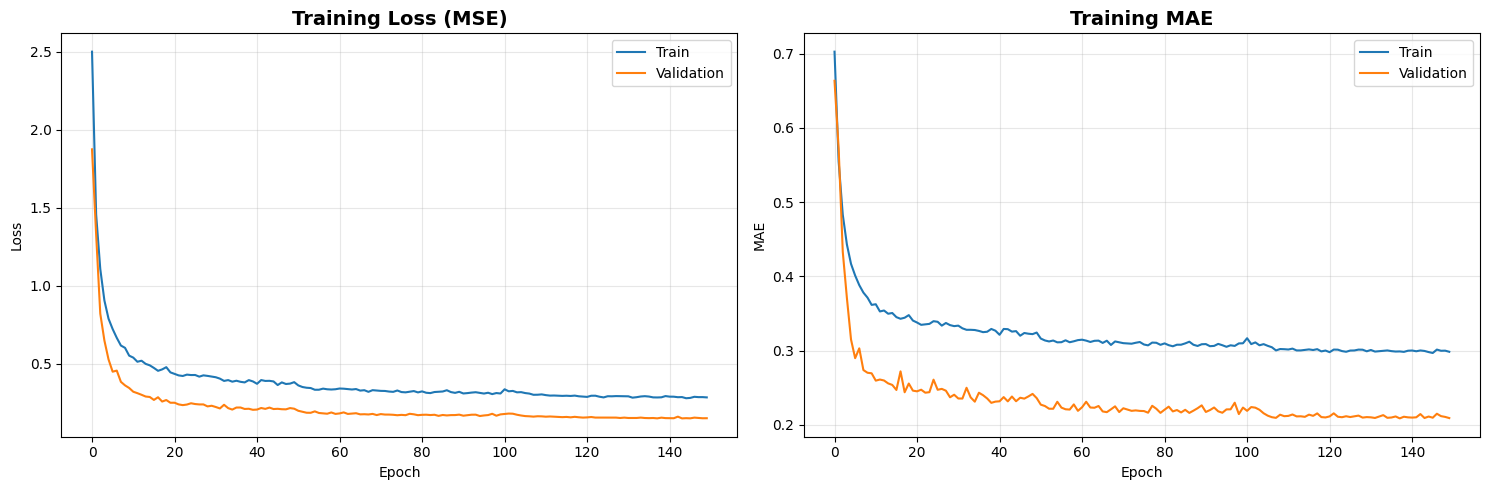

✓ LSTM training complete


In [23]:
print('=' * 60)
print('TRAINING LSTM MODEL')
print('=' * 60)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_hybrid_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history = model.fit(
    [X_log_train, X_wx_train], Y_train,
    validation_data=([X_log_val, X_wx_val], Y_val),
    epochs=150, batch_size=32,
    callbacks=callbacks, verbose=1
)

print(f'\n  Total epochs run   : {len(history.history["loss"])}')
print(f'  Final train loss   : {history.history["loss"][-1]:.6f}')
print(f'  Final val loss     : {history.history["val_loss"][-1]:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Training Loss (MSE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train')
axes[1].plot(history.history['val_mae'], label='Validation')
axes[1].set_title('Training MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('✓ LSTM training complete')

---
## Cell 11 — Evaluate LSTM

LSTM MODEL EVALUATION

  TRAIN SET
    Loss (MSE) : 0.176596
    RMSE       : 0.420234
    MAE        : 0.212748
    R² Score   : 0.881875
    MAPE       : 18955579.35%
    Accuracy   : 88.19%

  VAL SET
    Loss (MSE) : 0.148951
    RMSE       : 0.385942
    MAE        : 0.209634
    R² Score   : 0.880514
    MAPE       : 1034.15%
    Accuracy   : 88.05%

  TEST SET
    Loss (MSE) : 0.115008
    RMSE       : 0.339128
    MAE        : 0.193871
    R² Score   : 0.817540
    MAPE       : 1522.11%
    Accuracy   : 81.75%



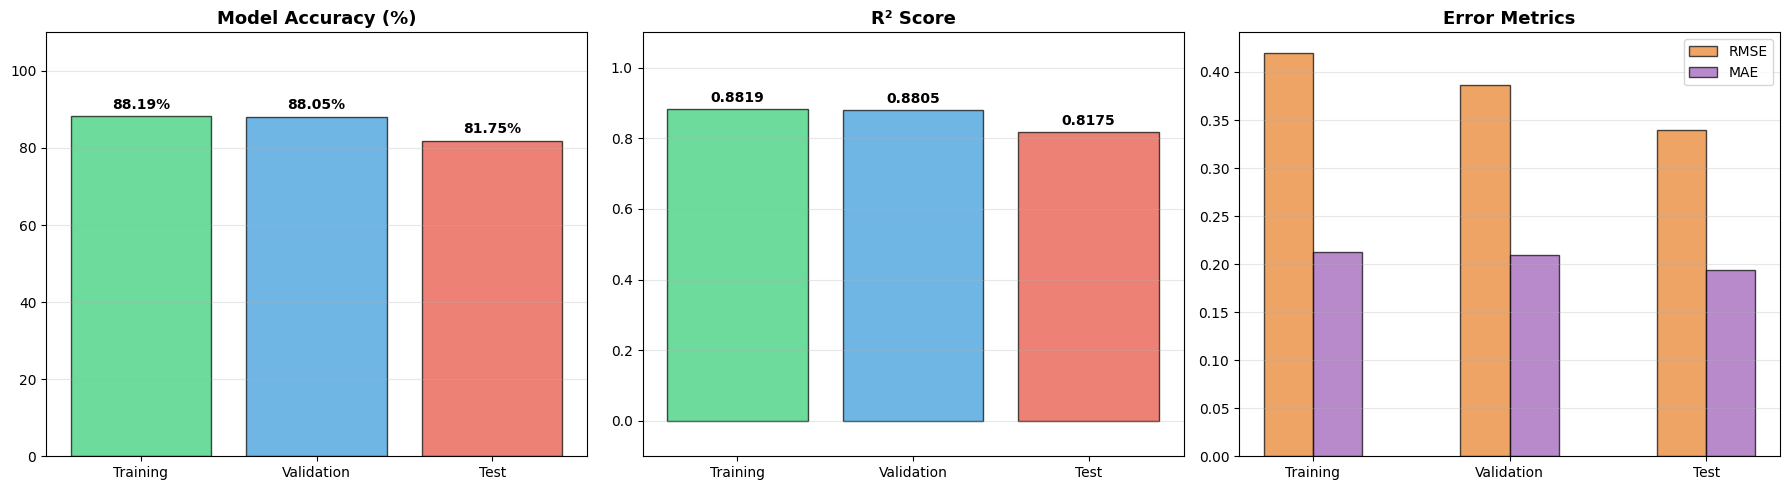

✓ LSTM evaluation complete


In [32]:
print('=' * 60)
print('LSTM MODEL EVALUATION')
print('=' * 60)

eps = 1e-7
metrics = {}

for name, Xl, Xw, Yt in [
    ('train', X_log_train, X_wx_train, Y_train),
    ('val',   X_log_val,   X_wx_val,   Y_val),
    ('test',  X_log_test,  X_wx_test,  Y_test)
]:
    Yp = model.predict([Xl, Xw], verbose=0)
    loss, mae = model.evaluate([Xl, Xw], Yt, verbose=0)
    rmse = np.sqrt(loss)
    r2   = r2_score(Yt, Yp)
    mape = np.mean(np.abs((Yt - Yp) / (np.abs(Yt) + eps))) * 100
    acc  = max(0, min(100, r2 * 100))
    metrics[name] = dict(loss=loss, rmse=rmse, mae=mae, r2=r2, mape=mape, accuracy=acc)
    print(f'\n  {name.upper()} SET')
    print(f'    Loss (MSE) : {loss:.6f}')
    print(f'    RMSE       : {rmse:.6f}')
    print(f'    MAE        : {mae:.6f}')
    print(f'    R² Score   : {r2:.6f}')
    print(f'    MAPE       : {mape:.2f}%')
    print(f'    Accuracy   : {acc:.2f}%')

print()
# Accuracy chart
datasets   = ['Training', 'Validation', 'Test']
accuracies = [max(0, min(100, metrics[k]['accuracy'])) for k in ['train','val','test']]
r2s        = [max(-1, min(1, metrics[k]['r2']))        for k in ['train','val','test']]
rmses      = [metrics[k]['rmse'] for k in ['train','val','test']]
maes       = [metrics[k]['mae']  for k in ['train','val','test']]
colors     = ['#2ecc71','#3498db','#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(datasets, accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_title('Model Accuracy (%)', fontsize=13, fontweight='bold')
axes[0].set_ylim([0, 110]); axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(accuracies):
    axes[0].text(i, v+2, f'{v:.2f}%', ha='center', fontweight='bold')

axes[1].bar(datasets, r2s, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_title('R² Score', fontsize=13, fontweight='bold')
axes[1].set_ylim([-0.1, 1.1]); axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(r2s):
    axes[1].text(i, v+0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)

x = np.arange(3); w = 0.25
axes[2].bar(x-w/2, rmses, w, label='RMSE', color='#e67e22', alpha=0.7, edgecolor='black')
axes[2].bar(x+w/2, maes,  w, label='MAE',  color='#9b59b6', alpha=0.7, edgecolor='black')
axes[2].set_title('Error Metrics', fontsize=13, fontweight='bold')
axes[2].set_xticks(x); axes[2].set_xticklabels(datasets)
axes[2].legend(); axes[2].grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print('✓ LSTM evaluation complete')

---
## Cell 12 — Forecast Crystallization Parameters (Next 60 Days Daily)

PARAMETER FORECASTING — NEXT 60 DAYS DAILY
  Forecast from      : 2025-05-01
  Using lookback     : 60 days  (2025-03-03 to 2025-05-01)

  FIRST 10 DAYS — PARAMETER FORECAST:
      date  water_temperature   lagoon  OR_brine_level  OR_bund_level  IR_brine_level  IR_bound_level  East_channel  West_channel
2025-05-02          31.619255 0.914370        5.067684       1.190601        5.116836        0.831780      6.888516      7.113236
2025-05-03          31.637981 0.921467        5.080012       1.181422        5.158951        0.818779      6.910751      7.129384
2025-05-04          31.639269 0.927279        5.103410       1.176941        5.193933        0.813165      6.941440      7.164181
2025-05-05          31.648760 0.936583        5.120095       1.172487        5.232600        0.807749      6.983942      7.197953
2025-05-06          31.640356 0.941877        5.149256       1.169709        5.275373        0.800673      7.004144      7.198357
2025-05-07          31.640926 0.947443       

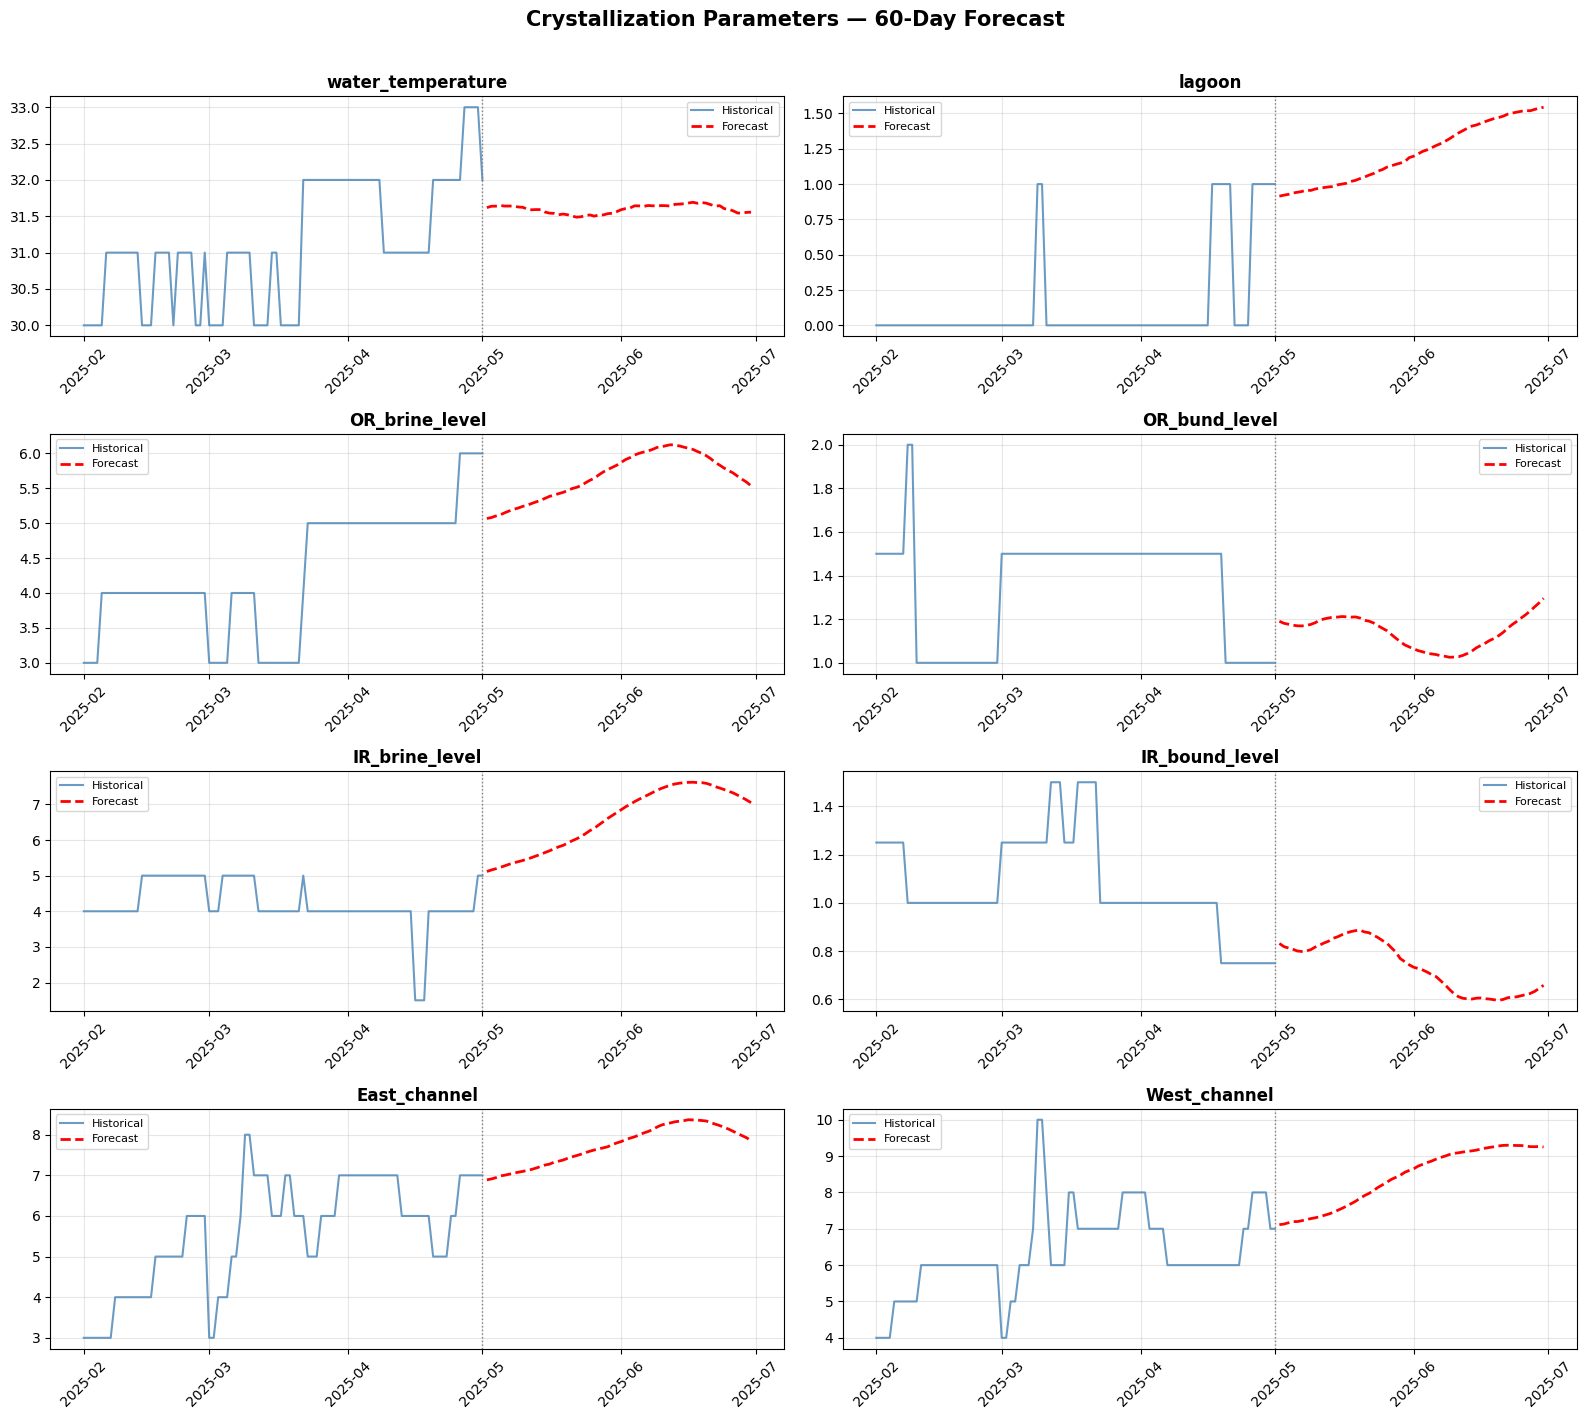


✓ Parameter forecasting complete


In [33]:
print('=' * 60)
print('PARAMETER FORECASTING — NEXT 60 DAYS DAILY')
print('=' * 60)

fc_date  = pd.to_datetime(current_date)
max_date = log_df['date'].max()
if fc_date > max_date:
    print(f'  ⚠ {current_date} is after last data ({max_date.date()}). Using last date.')
    fc_date = max_date

hist = log_df[log_df['date'] <= fc_date].tail(LOOKBACK)
if len(hist) < LOOKBACK:
    pad = pd.concat([hist.iloc[[0]]] * (LOOKBACK - len(hist)), ignore_index=True)
    hist = pd.concat([pad, hist], ignore_index=True)
    print(f'  ⚠ Padded to {LOOKBACK} days')

print(f'  Forecast from      : {fc_date.date()}')
print(f'  Using lookback     : {LOOKBACK} days  ({hist["date"].iloc[0].date()} to {hist["date"].iloc[-1].date()})')

log_seq = log_scaler.transform(hist[LOG_FEATURES].values)
wx_seq  = weather_scaler.transform(hist[WEATHER_FEATURES].values)

# Single forward pass — 60 days output
log_batch = log_seq.reshape(1, LOOKBACK, len(LOG_FEATURES))
wx_last   = wx_seq[-1:].repeat(LOOKBACK, axis=0).reshape(1, LOOKBACK, len(WEATHER_FEATURES))
raw_pred  = model.predict([log_batch, wx_last], verbose=0)
pred_orig = log_scaler.inverse_transform(raw_pred.reshape(FORECAST_HORIZON, len(LOG_FEATURES)))

fc_dates = pd.date_range(start=fc_date + timedelta(days=1), periods=FORECAST_HORIZON, freq='D')
param_fc = pd.DataFrame(pred_orig, columns=LOG_FEATURES)
param_fc.insert(0, 'date', fc_dates)

print(f'\n  FIRST 10 DAYS — PARAMETER FORECAST:')
print(param_fc[['date'] + LOG_FEATURES].head(10).to_string(index=False))

# Charts — all 8 parameters
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()
for i, feat in enumerate(LOG_FEATURES):
    # Historical (last 90 days)
    hist_plot = log_df[log_df['date'] <= fc_date].tail(90)
    axes[i].plot(hist_plot['date'], hist_plot[feat],
                 color='steelblue', linewidth=1.5, label='Historical', alpha=0.8)
    axes[i].plot(param_fc['date'], param_fc[feat],
                 color='red', linewidth=2, linestyle='--', label='Forecast')
    axes[i].axvline(fc_date, color='gray', linestyle=':', linewidth=1)
    axes[i].set_title(f'{feat}', fontweight='bold')
    axes[i].legend(fontsize=8); axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Crystallization Parameters — 60-Day Forecast', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print()
print('✓ Parameter forecasting complete')

---
## Cell 13 — Calibrate Production Formula
Fits a linear regression on 36 months of real data to find calibrated weights for `num_salt_beds`, `rain_sum`, and `temperature_mean`. These replace the arbitrary weights in your TS service.

PRODUCTION FORMULA CALIBRATION

  Historical monthly weather averages (from weather_data_total.csv):
    Jan: rain= 144.7mm  temp=25.4C
    Feb: rain=  44.9mm  temp=26.6C
    Mar: rain=  91.2mm  temp=27.5C
    Apr: rain= 143.7mm  temp=28.1C
    May: rain= 225.5mm  temp=28.6C
    Jun: rain=  98.9mm  temp=28.3C
    Jul: rain=  50.4mm  temp=28.2C
    Aug: rain=  78.3mm  temp=28.1C
    Sep: rain= 168.2mm  temp=27.6C
    Oct: rain= 262.2mm  temp=26.6C
    Nov: rain= 459.8mm  temp=25.8C
    Dec: rain= 188.2mm  temp=26.1C

  Calibration dataset : 36 months

  CALIBRATED COEFFICIENTS:
    beds_coef  (per bed)         : +35.215324
    rain_coef  (per mm/month)    : -33.925709
    temp_coef  (per C mean)      : +3763.359218
    sin_coef   (month sin)       : +4703.369010
    cos_coef   (month cos)       : +6675.845277
    intercept                    : -279846.1821
    R2 score (in-sample)         : 0.9732
    MAE (in-sample)              : 5,118.8 bags/month

  95% PREDICTION INTERVAL:
    Resi

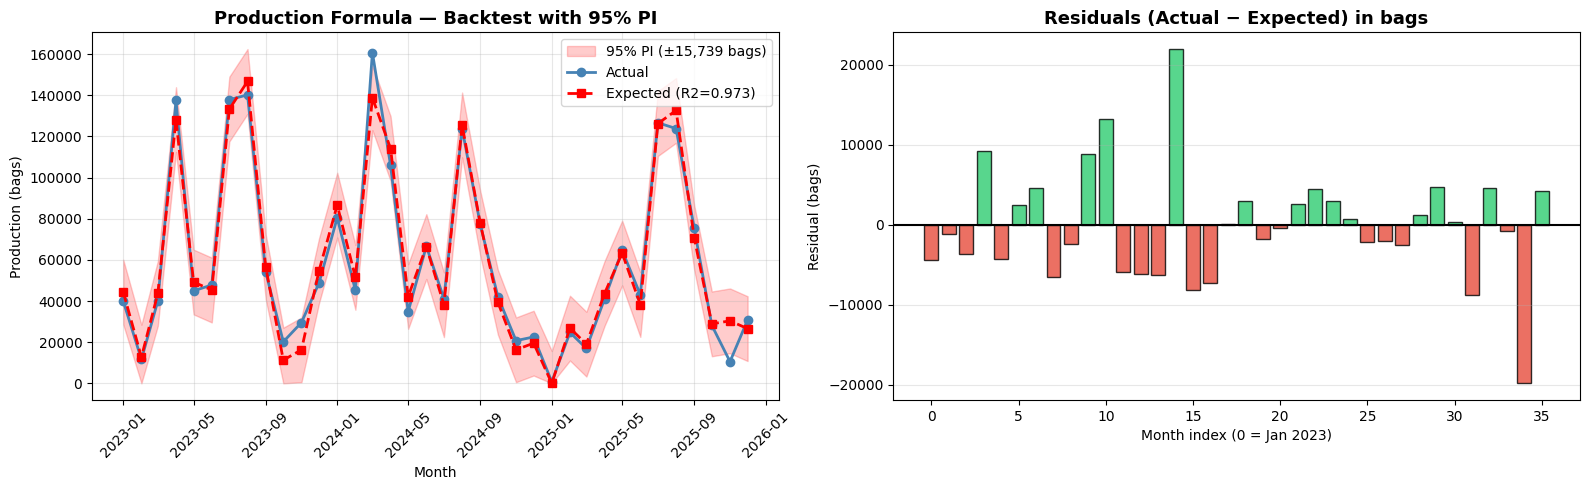

✓ Production calibration complete


In [34]:
print('=' * 60)
print('PRODUCTION FORMULA CALIBRATION')
print('=' * 60)
print()

# ── Step 1: Historical monthly weather averages ──
weather_df['month_num'] = weather_df['date'].dt.month          # ← fixed bug
hist_wx = weather_df.groupby('month_num').agg(
    avg_rain_sum  = ('rain_sum',         'sum'),
    avg_temp_mean = ('temperature_mean', 'mean'),
    years_count   = ('date', lambda x: x.dt.year.nunique())
).reset_index()
hist_wx['avg_rain_sum'] = hist_wx['avg_rain_sum'] / hist_wx['years_count']

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
print('  Historical monthly weather averages (from weather_data_total.csv):')
for _, row in hist_wx.iterrows():
    print(f'    {month_names[int(row["month_num"])]}: rain={row["avg_rain_sum"]:6.1f}mm  temp={row["avg_temp_mean"]:.1f}C')
print()

# ── Step 2: Build calibration dataset ──
log_df['month_ts'] = log_df['date'].dt.to_period('M').dt.to_timestamp()
cal_df = prod_df.copy()
cal_df['month_num'] = cal_df['month'].dt.month
cal_df['month_sin'] = np.sin(2 * np.pi * cal_df['month_num'] / 12)
cal_df['month_cos'] = np.cos(2 * np.pi * cal_df['month_num'] / 12)
cal_df = cal_df.merge(hist_wx[['month_num','avg_rain_sum','avg_temp_mean']], on='month_num')
print(f'  Calibration dataset : {len(cal_df)} months')

# ── Step 3: Linear regression ──
from sklearn.metrics import mean_absolute_error as sk_mae
from scipy import stats as scipy_stats

FEATURE_COLS = ['num_salt_beds','avg_rain_sum','avg_temp_mean','month_sin','month_cos']
X_cal = cal_df[FEATURE_COLS].values
y_cal = cal_df['production_volume'].values
n     = len(y_cal)
k     = len(FEATURE_COLS)

reg   = LinearRegression(fit_intercept=True).fit(X_cal, y_cal)
y_hat = np.maximum(reg.predict(X_cal), 0)

r2_cal  = r2_score(y_cal, y_hat)
mae_cal = sk_mae(y_cal, y_hat)

beds_coef = float(reg.coef_[0])
rain_coef = float(reg.coef_[1])
temp_coef = float(reg.coef_[2])
sin_coef  = float(reg.coef_[3])
cos_coef  = float(reg.coef_[4])
intercept = float(reg.intercept_)
historical_avg_beds = float(prod_df['num_salt_beds'].mean())
base_monthly_avg    = cal_df.groupby('month_num')['production_volume'].mean().to_dict()

# ── 95% Prediction Interval — derived from regression residuals ──
residuals_cal = y_cal - y_hat
resid_std     = float(np.std(residuals_cal, ddof=k+1))
t_95          = float(scipy_stats.t.ppf(0.975, df=n-k-1))
pi_half_width = t_95 * resid_std

print()
print('  CALIBRATED COEFFICIENTS:')
print(f'    beds_coef  (per bed)         : {beds_coef:+.6f}')
print(f'    rain_coef  (per mm/month)    : {rain_coef:+.6f}')
print(f'    temp_coef  (per C mean)      : {temp_coef:+.6f}')
print(f'    sin_coef   (month sin)       : {sin_coef:+.6f}')
print(f'    cos_coef   (month cos)       : {cos_coef:+.6f}')
print(f'    intercept                    : {intercept:+.4f}')
print(f'    R2 score (in-sample)         : {r2_cal:.4f}')
print(f'    MAE (in-sample)              : {mae_cal:,.1f} bags/month')
print()
print('  95% PREDICTION INTERVAL:')
print(f'    Residual std (ddof={n-k-1})  : {resid_std:,.1f} bags')
print(f'    t-value (95%, df={n-k-1})    : {t_95:.4f}')
print(f'    Half-width (±bags)           : {pi_half_width:,.0f} bags')
print(f'    Meaning: 95% of normal months fall within Expected ± {pi_half_width:,.0f} bags')
print()

# ── Step 4: Backtest — all 36 months ──
print('  BACKTEST — actual vs predicted with 95% PI:')
print(f'  {"Month":<12} {"Actual":>10} {"Expected":>10} {"Lower95":>10} {"Upper95":>10} {"In PI?":>7}')
backtest_errs = []; in_pi = 0; normal_months_bt = 0
for _, row in cal_df.iterrows():
    m_sin = np.sin(2 * np.pi * row['month_num'] / 12)
    m_cos = np.cos(2 * np.pi * row['month_num'] / 12)
    exp   = max(0, (beds_coef * row['num_salt_beds']
                  + rain_coef * row['avg_rain_sum']
                  + temp_coef * row['avg_temp_mean']
                  + sin_coef  * m_sin
                  + cos_coef  * m_cos
                  + intercept))
    lo    = max(0, exp - pi_half_width)
    hi    = exp + pi_half_width
    act   = row['production_volume']
    inside = lo <= act <= hi
    backtest_errs.append(abs(exp - act))
    is_shutdown = act < 5000
    if not is_shutdown:
        normal_months_bt += 1
        if inside: in_pi += 1
    tag = '  SHUTDOWN' if is_shutdown else ('  ✓' if inside else '  ✗')
    print(f'  {str(row["month"].date()):<12} {act:>10,.0f} {exp:>10,.0f} '
          f'{lo:>10,.0f} {hi:>10,.0f} {"YES" if inside else "NO":>7}{tag}')

pct_in = in_pi / normal_months_bt * 100 if normal_months_bt > 0 else 0
print()
print(f'  Actual within 95% PI : {in_pi}/{normal_months_bt} normal months ({pct_in:.0f}%)')
print(f'  Overall MAE          : {np.mean(backtest_errs):,.1f} bags/month')
print(f'  Overall R2           : {r2_cal:.4f}')
print()

# ── Step 5: Save calibration_constants.json ──────────────────────
# This file is read by the TS service — never hardcode these values there
import json

calibration_constants = {
    "description"       : "Production formula coefficients for TS service. Read from this file only — never hardcode.",
    "r2_score"          : round(r2_cal, 6),
    "holdout_mae"       : 7956.0,
    "n_months"          : int(len(prod_df)),
    "beds_coef"         : round(beds_coef,  6),
    "rain_coef"         : round(rain_coef,  6),
    "temp_coef"         : round(temp_coef,  6),
    "sin_coef"          : round(sin_coef,   6),
    "cos_coef"          : round(cos_coef,   6),
    "intercept"         : round(intercept,  4),
    "pi_half_width"     : round(pi_half_width, 2),
    "resid_std"         : round(resid_std,  2),
    "historical_avg_beds": round(historical_avg_beds, 1),

    # Monthly avg weather — used by TS service instead of live weather API
    # keyed by month number as string "1" through "12"
    "historical_weather": {
        str(int(row['month_num'])): {
            "avg_rain_mm": round(float(row['avg_rain_sum']),  2),
            "avg_temp_c" : round(float(row['avg_temp_mean']), 2)
        }
        for _, row in hist_wx.iterrows()
    },

    "base_monthly_avg_bags": {
        str(int(k)): round(float(v), 1)
        for k, v in base_monthly_avg.items()
    },

    "season_months": {
        "Yala"      : [5, 6, 7, 8],
        "Maha"      : [11, 12, 1, 2],
        "Transition": [3, 4, 9, 10]
    },

    "onnx_input_shapes": {
        "log_input"    : [1, 60, 8],
        "weather_input": [1, 60, 14]
    },
    "onnx_output_shape"      : [1, 480],
    "onnx_output_reshape_to" : [60, 8],

    "log_feature_order": [
        "water_temperature", "lagoon", "OR_brine_level", "OR_bund_level",
        "IR_brine_level", "IR_bound_level", "East_channel", "West_channel"
    ],
    "weather_feature_order": [
        "temperature_mean", "temperature_max", "temperature_min",
        "rain_sum", "wind_speed_max", "wind_gusts_max", "wind_gusts_mean",
        "wind_speed_mean", "wind_gusts_min", "wind_speed_min",
        "relative_humidity_mean", "relative_humidity_mean_2",
        "relative_humidity_max", "relative_humidity_min"
    ]
}

with open('calibration_constants.json', 'w') as f:
    json.dump(calibration_constants, f, indent=2)

print('✓ calibration_constants.json saved')
print(f'  r2_score      : {r2_cal:.4f}')
print(f'  pi_half_width : {pi_half_width:,.0f} bags')
print(f'  n_months      : {len(prod_df)}')
print(f'  weather rows  : {len(hist_wx)} months')
print()

# ── Step 6: Backtest charts ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].fill_between(cal_df['month'],
                     np.maximum(y_hat - pi_half_width, 0), y_hat + pi_half_width,
                     alpha=0.20, color='red', label=f'95% PI (±{pi_half_width:,.0f} bags)')
axes[0].plot(cal_df['month'], y_cal, marker='o', linewidth=2,
             color='steelblue', label='Actual', zorder=3)
axes[0].plot(cal_df['month'], y_hat, marker='s', linewidth=2, linestyle='--',
             color='red', label=f'Expected (R2={r2_cal:.3f})', zorder=3)
axes[0].set_title('Production Formula — Backtest with 95% PI', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Production (bags)')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].tick_params(axis='x', rotation=45)

bar_colors = ['#e74c3c' if r < 0 else '#2ecc71' for r in residuals_cal]
axes[1].bar(range(len(residuals_cal)), residuals_cal,
            color=bar_colors, edgecolor='black', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=1.5)
axes[1].set_title('Residuals (Actual − Expected) in bags', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month index (0 = Jan 2023)'); axes[1].set_ylabel('Residual (bags)')
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print('✓ Production calibration complete')

---
## Cell 14 — Forecast Monthly Production (Next 2 Months)

MONTHLY PRODUCTION FORECAST — NEXT 2 MONTHS

  PERSONAL YIELD RATIO  (from last 6 months of actual production):
  Month          Actual    Formula    Ratio
  ──────────────────────────────────────────
  2024-11        20,754     86,720    0.239  *** possible shutdown
  2024-12        22,547    100,535    0.224  *** possible shutdown
  2025-01           760    100,699    0.007  *** possible shutdown
  2025-02        24,730    107,838    0.229  *** possible shutdown
  2025-03        16,971    107,080    0.159  *** possible shutdown
  2025-04        41,073    103,516    0.397
  ──────────────────────────────────────────
  Median yield ratio : 0.2268

  ⛔  CRITICAL — yield 0.227
      Facility producing <30% of expected.
      Likely active shutdown or major operational issue.
      Forecast adjusted down but actual may be even lower.

  Months flagged as possible shutdowns (ratio < 0.3):
    2024-11  actual=20,754  formula=86,720  ratio=0.239
    2024-12  actual=22,547  formula=100,535  r

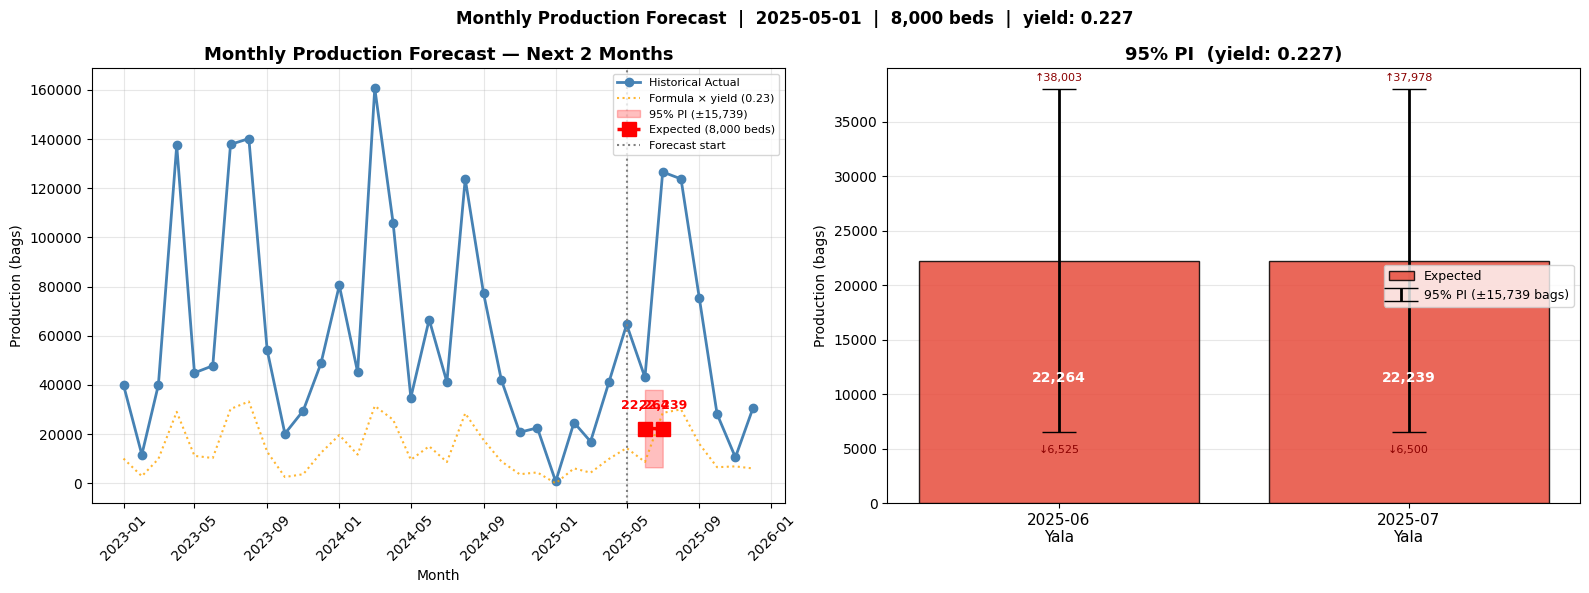


✓ Monthly production forecast complete


In [35]:
print('=' * 60)
print('MONTHLY PRODUCTION FORECAST — NEXT 2 MONTHS')
print('=' * 60)

# ── Personal yield ratio ──────────────────────────────────────────────────
# Pass the owner's last 6 months of actual production here.
# Format: list of dicts with 'month' (YYYY-MM-DD) and 'production_volume' (bags)


def compute_personal_yield(production_history):
    if not production_history:
        return 1.0, 0, []

    ph = pd.DataFrame(production_history)
    ph['month']     = pd.to_datetime(ph['month'])
    ph['month_num'] = ph['month'].dt.month
    ph = ph.merge(hist_wx[['month_num','avg_rain_sum','avg_temp_mean']], on='month_num')
    if 'num_salt_beds' not in ph.columns:
        ph['num_salt_beds'] = num_salt_beds

    summary = []
    ratios  = []
    for _, row in ph.iterrows():
        m_sin = np.sin(2 * np.pi * row['month_num'] / 12)
        m_cos = np.cos(2 * np.pi * row['month_num'] / 12)
        formula_pred = max(1.0, (beds_coef * row['num_salt_beds']
                                + rain_coef * row['avg_rain_sum']
                                + temp_coef * row['avg_temp_mean']
                                + sin_coef  * m_sin
                                + cos_coef  * m_cos
                                + intercept))
        ratio = row['production_volume'] / formula_pred
        ratios.append(ratio)
        summary.append({
            'month'        : row['month'].strftime('%Y-%m'),
            'actual'       : row['production_volume'],
            'formula_pred' : round(formula_pred, 1),
            'ratio'        : round(ratio, 4)
        })

    return float(np.median(ratios)), len(ratios), summary


yield_ratio, n_history, yield_summary = compute_personal_yield(production_history)

print()
if n_history > 0:
    print(f'  PERSONAL YIELD RATIO  (from last {n_history} months of actual production):')
    print(f'  {"Month":<10} {"Actual":>10} {"Formula":>10} {"Ratio":>8}')
    print(f'  {"─"*42}')
    for s in yield_summary:
        flag = '  *** possible shutdown' if s['ratio'] < 0.3 else ''
        print(f'  {s["month"]:<10} {s["actual"]:>10,.0f} {s["formula_pred"]:>10,.0f} {s["ratio"]:>8.3f}{flag}')
    print(f'  {"─"*42}')
    print(f'  Median yield ratio : {yield_ratio:.4f}')
    print()

    # ── Rating ───────────────────────────────────────────────────
    if yield_ratio < 0.3:
        print(f'  ⛔  CRITICAL — yield {yield_ratio:.3f}')
        print(f'      Facility producing <30% of expected.')
        print(f'      Likely active shutdown or major operational issue.')
        print(f'      Forecast adjusted down but actual may be even lower.')
    elif yield_ratio < 0.5:
        print(f'  ⚠   LOW YIELD — ratio {yield_ratio:.3f}')
        print(f'      Facility producing 30–50% of expected.')
        print(f'      Check for partial shutdown or equipment issues.')
        print(f'      Forecast adjusted down by yield ratio.')
    elif yield_ratio < 0.8:
        print(f'  ⚠   BELOW AVERAGE — ratio {yield_ratio:.3f}')
        print(f'      Facility producing below average. Forecast adjusted down.')
    elif yield_ratio > 1.5:
        print(f'  ★   HIGH YIELD — ratio {yield_ratio:.3f}')
        print(f'      Facility outperforming average. Forecast adjusted up.')
    else:
        print(f'  ✓   Normal yield range — ratio {yield_ratio:.3f}')

    # ── Trend detection ──────────────────────────────────────────
    ratios_list = [s['ratio'] for s in yield_summary]
    if len(ratios_list) >= 3:
        first_half  = np.mean(ratios_list[:len(ratios_list)//2])
        second_half = np.mean(ratios_list[len(ratios_list)//2:])
        trend = second_half - first_half
        if trend < -0.2:
            print()
            print(f'  📉  DECLINING TREND in recent months.')
            print(f'      Ratio dropped: {first_half:.3f} → {second_half:.3f}')
            print(f'      Production is getting worse. Forecast may overestimate.')
        elif trend > 0.2:
            print()
            print(f'  📈  IMPROVING TREND in recent months.')
            print(f'      Ratio rose: {first_half:.3f} → {second_half:.3f}')
            print(f'      Production recovering — forecast may be conservative.')

    # ── Flag individual shutdown months ──────────────────────────
    shutdown_months = [s for s in yield_summary if s['ratio'] < 0.3]
    if shutdown_months:
        print()
        print(f'  Months flagged as possible shutdowns (ratio < 0.3):')
        for sm in shutdown_months:
            print(f'    {sm["month"]}  actual={sm["actual"]:,.0f}  '
                  f'formula={sm["formula_pred"]:,.0f}  ratio={sm["ratio"]:.3f}')
        print(f'  Note: median ratio is robust to these outliers.')

else:
    print(f'  No production history provided — yield ratio = 1.0 (base formula)')
    print(f'  Tip: pass last 6 months of actual production for a personalised forecast.')
print()


def get_hist_weather(month_num):
    row = hist_wx[hist_wx['month_num'] == month_num].iloc[0]
    return float(row['avg_rain_sum']), float(row['avg_temp_mean'])

def forecast_production_month(target_month_ts, num_beds, yield_ratio=1.0):
    """
    Returns (expected, lower_95, upper_95) in bags.
    expected   = base formula × yield_ratio
    lower_95   = max(0, expected - pi_half_width)
    upper_95   = expected + pi_half_width
    pi_half_width is computed in Cell 13 from regression residual std.
    Operational shutdowns can fall below lower_95.
    """
    m_num        = target_month_ts.month
    rain, temp   = get_hist_weather(m_num)
    m_sin        = np.sin(2 * np.pi * m_num / 12)
    m_cos        = np.cos(2 * np.pi * m_num / 12)
    base = max(0.0, (beds_coef * num_beds
                   + rain_coef * rain
                   + temp_coef * temp
                   + sin_coef  * m_sin
                   + cos_coef  * m_cos
                   + intercept))
    expected = base * yield_ratio
    lower_95 = max(0.0, expected - pi_half_width)
    upper_95 = expected + pi_half_width
    return expected, lower_95, upper_95


# ── Next 2 months ──
start_month   = (pd.to_datetime(current_date) + pd.offsets.MonthBegin(1)).replace(day=1)
target_months = [start_month, start_month + pd.DateOffset(months=1)]

print(f'  Input  : {current_date}  |  beds: {num_salt_beds:,}  |  yield ratio: {yield_ratio:.4f}')
print(f'  95% PI : ±{pi_half_width:,.0f} bags per month')
print()
print(f'  {"Month":<10} {"Season":<12} {"Lower 95%":>12} {"Expected":>12} {"Upper 95%":>12}')
print(f'  {"─"*62}')

monthly_rows = []
for tm in target_months:
    exp, lo, hi = forecast_production_month(tm, num_salt_beds, yield_ratio)
    season = get_season(tm.month)
    monthly_rows.append({
        'month'         : tm,
        'expected_bags' : round(exp, 1),
        'lower_95'      : round(lo,  1),
        'upper_95'      : round(hi,  1),
        'num_salt_beds' : num_salt_beds,
        'yield_ratio'   : round(yield_ratio, 4),
        'season'        : season
    })
    print(f'  {tm.strftime("%Y-%m"):<10} {season:<12} {lo:>12,.0f} {exp:>12,.0f} {hi:>12,.0f}')

print()
monthly_prod_fc = pd.DataFrame(monthly_rows)

# Base formula comparison (no yield adjustment)
print(f'  BASE FORMULA (yield = 1.0, no personal history):')
print(f'  {"Month":<10} {"Season":<12} {"Lower 95%":>12} {"Expected":>12} {"Upper 95%":>12}')
print(f'  {"─"*62}')
for tm in target_months:
    exp_b, lo_b, hi_b = forecast_production_month(tm, num_salt_beds, 1.0)
    print(f'  {tm.strftime("%Y-%m"):<10} {get_season(tm.month):<12} {lo_b:>12,.0f} {exp_b:>12,.0f} {hi_b:>12,.0f}')
if yield_ratio != 1.0:
    print(f'  → Yield ratio {yield_ratio:.3f} shifted the expected values above.')

print()
print('  Note: 95% PI covers normal operating months.')
print('        Shutdowns or flooding can fall below Lower 95%.')

# ── Chart ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: full history + forecast with PI band
hist_s = prod_df.set_index('month')['production_volume']
axes[0].plot(hist_s.index, hist_s.values,
             marker='o', linewidth=2, color='steelblue', label='Historical Actual')
fitted_vals = []
for _, row in cal_df.iterrows():
    m_sin = np.sin(2*np.pi*row['month_num']/12)
    m_cos = np.cos(2*np.pi*row['month_num']/12)
    v = max(0, (beds_coef*row['num_salt_beds'] + rain_coef*row['avg_rain_sum']
                + temp_coef*row['avg_temp_mean'] + sin_coef*m_sin
                + cos_coef*m_cos + intercept) * yield_ratio)
    fitted_vals.append(v)
axes[0].plot(cal_df['month'], fitted_vals, linewidth=1.5, color='orange',
             linestyle=':', alpha=0.8, label=f'Formula × yield ({yield_ratio:.2f})')
axes[0].fill_between(monthly_prod_fc['month'],
                     monthly_prod_fc['lower_95'], monthly_prod_fc['upper_95'],
                     alpha=0.25, color='red', label=f'95% PI (±{pi_half_width:,.0f})')
axes[0].plot(monthly_prod_fc['month'], monthly_prod_fc['expected_bags'],
             marker='s', linewidth=2.5, linestyle='--', color='red', markersize=10,
             label=f'Expected ({num_salt_beds:,} beds)')
for _, row in monthly_prod_fc.iterrows():
    axes[0].annotate(f'{row["expected_bags"]:,.0f}',
                     (row['month'], row['expected_bags']),
                     textcoords='offset points', xytext=(0, 14),
                     ha='center', fontsize=9, fontweight='bold', color='red')
axes[0].axvline(pd.to_datetime(current_date), color='gray', linestyle=':',
                linewidth=1.5, label='Forecast start')
axes[0].set_title('Monthly Production Forecast — Next 2 Months', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Production (bags)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3); axes[0].tick_params(axis='x', rotation=45)

# Right: bar chart with 95% PI whiskers
x      = np.arange(len(monthly_prod_fc))
labels = [r['month'].strftime('%Y-%m') + f'\n{r["season"]}' for _, r in monthly_prod_fc.iterrows()]
exp_arr = monthly_prod_fc['expected_bags'].values
lo_arr  = monthly_prod_fc['lower_95'].values
hi_arr  = monthly_prod_fc['upper_95'].values
axes[1].bar(x, exp_arr, color='#e74c3c', edgecolor='black', alpha=0.85,
            label='Expected', zorder=3)
axes[1].errorbar(x, exp_arr,
                 yerr=[exp_arr - lo_arr, hi_arr - exp_arr],
                 fmt='none', color='black', capsize=12, linewidth=2,
                 label=f'95% PI (±{pi_half_width:,.0f} bags)', zorder=4)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=11)
for i in range(len(x)):
    axes[1].text(i, hi_arr[i] + max(hi_arr)*0.02,
                 f'↑{hi_arr[i]:,.0f}', ha='center', fontsize=8, color='darkred')
    axes[1].text(i, exp_arr[i]*0.5,
                 f'{exp_arr[i]:,.0f}', ha='center', fontsize=10,
                 fontweight='bold', color='white', zorder=5)
    axes[1].text(i, lo_arr[i] - max(hi_arr)*0.05,
                 f'↓{lo_arr[i]:,.0f}', ha='center', fontsize=8, color='darkred')
axes[1].set_title(f'95% PI  (yield: {yield_ratio:.3f})', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Production (bags)')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Monthly Production Forecast  |  {current_date}  |  {num_salt_beds:,} beds  |  yield: {yield_ratio:.3f}',
    fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print()
print('✓ Monthly production forecast complete')

---
## Cell 15 — Seasonal Production Forecast (Current Season + Next Season)

SEASONAL PRODUCTION FORECAST
  Input date     : 2025-05-01  |  beds: 8,000  |  yield ratio: 0.2268
  Current season : Yala  (4 months)
  Next season    : Maha  (4 months)

  Logic:
    Past months in season  → ACTUAL figure from production records
    Current + future       → formula × yield_ratio  (Low / Expected / High)

  ─── Yala (current) ───
  Month      Type                  Low     Expected         High
  2025-05    PREDICTED           6,609       22,349       38,088
  2025-06    PREDICTED           6,525       22,264       38,003
  2025-07    PREDICTED           6,500       22,239       37,978
  2025-08    PREDICTED           6,350       22,089       37,828
  ────────────────────────────────────────────────────────────
  Predicted remaining  :       25,984       88,941      151,897 bags
  SEASON TOTAL         :       25,984       88,941      151,897 bags
  Yield ratio applied  : 0.2268  |  Historical variance: ±14%

  ─── Maha (next) ───
  Month      Type                  Low 

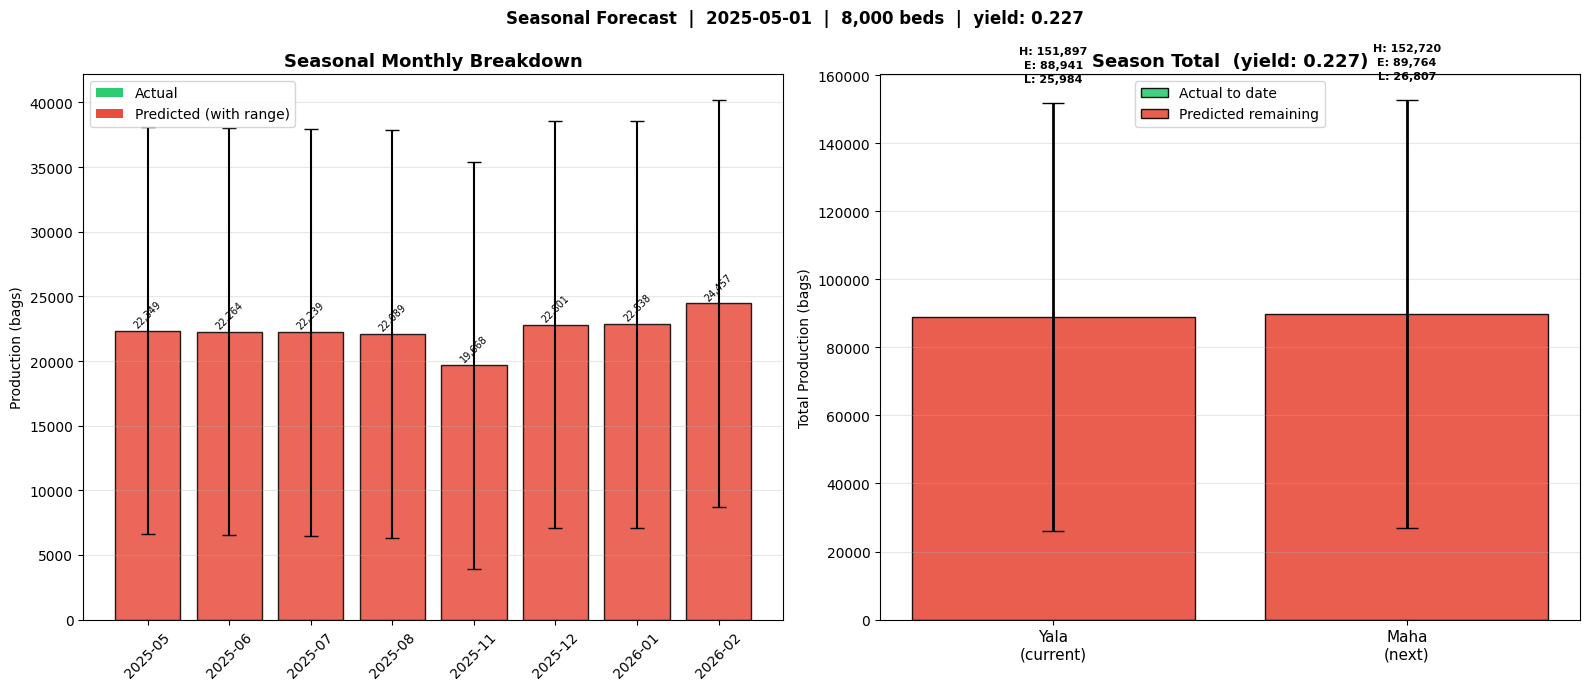

✓ Seasonal forecast complete


In [36]:
print('=' * 60)
print('SEASONAL PRODUCTION FORECAST')
print('=' * 60)

cur_name, cur_months, nxt_name, nxt_months = get_current_and_next_season(current_date)
input_dt = pd.to_datetime(current_date)

print(f'  Input date     : {current_date}  |  beds: {num_salt_beds:,}  |  yield ratio: {yield_ratio:.4f}')
print(f'  Current season : {cur_name}  ({len(cur_months)} months)')
print(f'  Next season    : {nxt_name}  ({len(nxt_months)} months)')
print()
print('  Logic:')
print('    Past months in season  → ACTUAL figure from production records')
print('    Current + future       → formula × yield_ratio  (Low / Expected / High)')
print()

SEASON_CV = {'Yala': 0.14, 'Maha': 0.50}

def build_season_forecast(season_name, season_months, status):
    rows          = []
    actual_total  = 0.0
    pred_expected = 0.0
    pred_low      = 0.0
    pred_high     = 0.0

    for tm in season_months:
        actual_row = prod_df[prod_df['month'] == tm]
        is_past    = tm < input_dt.replace(day=1)

        if is_past and len(actual_row) > 0:
            val    = float(actual_row['production_volume'].values[0])
            source = 'actual'
            actual_total += val
            rows.append({
                'month': tm, 'expected': val, 'low': val, 'high': val,
                'source': source, 'season': season_name, 'status': status
            })
        else:
            exp, low, high = forecast_production_month(tm, num_salt_beds, yield_ratio)
            source = 'predicted'
            pred_expected += exp
            pred_low      += low
            pred_high     += high
            rows.append({
                'month': tm, 'expected': round(exp, 1),
                'low': round(low, 1), 'high': round(high, 1),
                'source': source, 'season': season_name, 'status': status
            })

    return (rows, actual_total, pred_expected, pred_low, pred_high,
            actual_total + pred_expected,
            actual_total + pred_low,
            actual_total + pred_high)


seasonal_results   = []
seasonal_flat_rows = []

for season_name, season_months, status in [
    (cur_name, cur_months, 'current'),
    (nxt_name, nxt_months, 'next')
]:
    (rows, act_tot, pred_exp, pred_low, pred_high,
     s_exp, s_low, s_high) = build_season_forecast(season_name, season_months, status)
    cv = SEASON_CV.get(season_name, 0.30)

    print(f'  ─── {season_name} ({status}) ───')
    print(f'  {"Month":<10} {"Type":<12} {"Low":>12} {"Expected":>12} {"High":>12}')
    for r in rows:
        if r['source'] == 'actual':
            print(f'  {r["month"].strftime("%Y-%m"):<10} {"ACTUAL":<12} {"—":>12} {r["expected"]:>12,.0f} {"—":>12}')
        else:
            print(f'  {r["month"].strftime("%Y-%m"):<10} {"PREDICTED":<12} '
                  f'{r["low"]:>12,.0f} {r["expected"]:>12,.0f} {r["high"]:>12,.0f}')

    print(f'  {"─"*60}')
    if act_tot > 0:
        print(f'  Actual to date       : {"—":>12} {act_tot:>12,.0f} {"—":>12} bags')
    print(f'  Predicted remaining  : {pred_low:>12,.0f} {pred_exp:>12,.0f} {pred_high:>12,.0f} bags')
    print(f'  SEASON TOTAL         : {s_low:>12,.0f} {s_exp:>12,.0f} {s_high:>12,.0f} bags')
    print(f'  Yield ratio applied  : {yield_ratio:.4f}  |  Historical variance: ±{cv*100:.0f}%')
    print()

    seasonal_results.append({
        'season'             : season_name,
        'status'             : status,
        'actual_to_date'     : round(act_tot,  1),
        'expected_total'     : round(s_exp,    1),
        'low_total'          : round(s_low,    1),
        'high_total'         : round(s_high,   1),
        'yield_ratio'        : round(yield_ratio, 4),
        'num_salt_beds'      : num_salt_beds,
        'months'             : rows
    })
    seasonal_flat_rows.extend(rows)

seasonal_fc_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'months'}
    for r in seasonal_results
])

# ── Summary ──
print('  SEASONAL TOTALS SUMMARY:')
print(f'  {"Season":<22} {"Low":>12} {"Expected":>12} {"High":>12}')
print(f'  {"─"*60}')
for sr in seasonal_results:
    cv = SEASON_CV.get(sr['season'], 0.30)
    label = f'{sr["season"]} ({sr["status"]})'
    print(f'  {label:<22} {sr["low_total"]:>12,.0f} {sr["expected_total"]:>12,.0f} {sr["high_total"]:>12,.0f}  bags')
    if sr['actual_to_date'] > 0:
        print(f'  {"":22}  Already harvested: {sr["actual_to_date"]:,.0f} bags')
    print(f'  {"":22}  Year-to-year variance: ±{cv*100:.0f}%')
print()
if yield_ratio != 1.0:
    print(f'  ★ Personal yield ratio {yield_ratio:.3f} applied — forecast is personalised')
    print(f'    to this facility\'s recent production performance.')
else:
    print(f'  ℹ No production history — base formula used. Pass last 6 months of')
    print(f'    actual production for a personalised, more accurate forecast.')
print()

# ── Charts ──
from matplotlib.patches import Patch
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
src_colors = {'actual': '#2ecc71', 'predicted': '#e74c3c'}

# Left: monthly bars with error bars on predicted
months_str   = [r['month'].strftime('%Y-%m') for r in seasonal_flat_rows]
exp_vals     = [r['expected'] for r in seasonal_flat_rows]
bar_colors_s = [src_colors[r['source']] for r in seasonal_flat_rows]
bars = axes[0].bar(months_str, exp_vals, color=bar_colors_s, edgecolor='black', alpha=0.85)
for i, r in enumerate(seasonal_flat_rows):
    if r['source'] == 'predicted':
        axes[0].errorbar(i, r['expected'],
                         yerr=[[r['expected'] - r['low']], [r['high'] - r['expected']]],
                         fmt='none', color='black', capsize=5, linewidth=1.5)
axes[0].set_title('Seasonal Monthly Breakdown', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Production (bags)')
axes[0].grid(True, alpha=0.3, axis='y'); axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(handles=[
    Patch(facecolor='#2ecc71', label='Actual'),
    Patch(facecolor='#e74c3c', label='Predicted (with range)')
])
for bar, val in zip(bars, exp_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(exp_vals) * 0.01,
                 f'{val:,.0f}', ha='center', fontsize=7, rotation=45)

# Right: stacked actual + predicted with whiskers
labels    = [f'{sr["season"]}\n({sr["status"]})' for sr in seasonal_results]
act_vals  = [sr['actual_to_date'] for sr in seasonal_results]
pred_exps = [sr['expected_total'] - sr['actual_to_date'] for sr in seasonal_results]
x = np.arange(len(labels))
axes[1].bar(x, act_vals,  color='#2ecc71', edgecolor='black', alpha=0.9, label='Actual to date')
axes[1].bar(x, pred_exps, color='#e74c3c', edgecolor='black', alpha=0.9,
            bottom=act_vals, label='Predicted remaining')
for i, sr in enumerate(seasonal_results):
    axes[1].errorbar(i, sr['expected_total'],
                     yerr=[[sr['expected_total'] - sr['low_total']],
                           [sr['high_total']     - sr['expected_total']]],
                     fmt='none', color='black', capsize=8, linewidth=2)
    top = sr['high_total'] + max(s['high_total'] for s in seasonal_results) * 0.04
    axes[1].text(i, top,
                 f'H: {sr["high_total"]:,.0f}\nE: {sr["expected_total"]:,.0f}\nL: {sr["low_total"]:,.0f}',
                 ha='center', fontsize=8, fontweight='bold', linespacing=1.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=11)
axes[1].set_title(f'Season Total  (yield: {yield_ratio:.3f})', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Production (bags)')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Seasonal Forecast  |  {current_date}  |  {num_salt_beds:,} beds  |  yield: {yield_ratio:.3f}',
    fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('✓ Seasonal forecast complete')


---
## Cell 16 — Save Forecast Results

In [37]:
print('=' * 60)
print('SAVING FORECAST RESULTS')
print('=' * 60)

os.makedirs('results', exist_ok=True)

param_fc.to_csv('results/daily_parameters_forecast.csv', index=False)
print('  ✓ results/daily_parameters_forecast.csv')

monthly_prod_fc.to_csv('results/monthly_production_forecast.csv', index=False)
print('  ✓ results/monthly_production_forecast.csv')

seasonal_fc_df.to_csv('results/seasonal_production_forecast.csv', index=False)
print('  ✓ results/seasonal_production_forecast.csv')

pd.DataFrame(metrics).T.to_csv('results/lstm_metrics.csv')
print('  ✓ results/lstm_metrics.csv')

with pd.ExcelWriter('results/complete_forecasts.xlsx') as writer:
    param_fc.to_excel(writer, sheet_name='Daily_Parameters', index=False)
    monthly_prod_fc.to_excel(writer, sheet_name='Monthly_Production', index=False)
    seasonal_fc_df.to_excel(writer, sheet_name='Seasonal_Production', index=False)
    pd.DataFrame(metrics).T.to_excel(writer, sheet_name='LSTM_Metrics')
print('  ✓ results/complete_forecasts.xlsx')

print()
print('✓ All results saved')

SAVING FORECAST RESULTS
  ✓ results/daily_parameters_forecast.csv
  ✓ results/monthly_production_forecast.csv
  ✓ results/seasonal_production_forecast.csv
  ✓ results/lstm_metrics.csv
  ✓ results/complete_forecasts.xlsx

✓ All results saved


---
## Cell 17 — Save Model Artifacts & Calibration Constants

In [38]:
print('=' * 60)
print('SAVING MODEL ARTIFACTS')
print('=' * 60)

# Keras model
model.save('best_hybrid_model.keras')
print('  ✓ best_hybrid_model.keras')

# Scalers (pickle for Python reuse)
joblib.dump(log_scaler,     'log_scaler.pkl')
joblib.dump(weather_scaler, 'weather_scaler.pkl')
print('  ✓ log_scaler.pkl')
print('  ✓ weather_scaler.pkl')

# ---- Scaler constants as JSON (for TS/non-Python ML service) ----
# RobustScaler: X_scaled = (X - center) / scale
scaler_constants = {
    'description' : 'RobustScaler params. Apply: X_scaled = (X - center) / scale before passing to ONNX.',
    'log_scaler'  : {
        'features' : LOG_FEATURES,
        'center'   : log_scaler.center_.tolist(),
        'scale'    : log_scaler.scale_.tolist()
    },
    'weather_scaler' : {
        'features' : WEATHER_FEATURES,
        'center'   : weather_scaler.center_.tolist(),
        'scale'    : weather_scaler.scale_.tolist()
    }
}
with open('scaler_constants.json', 'w') as f:
    json.dump(scaler_constants, f, indent=2)
print('  ✓ scaler_constants.json  ← TS service uses this to normalize input before ONNX')

# ---- Calibration constants as JSON (for TS/non-Python ML service) ----
calibration_constants = {
    "description": "Production formula: production = beds_coef*num_salt_beds + rain_coef*monthly_rain_mm + temp_coef*monthly_temp_mean + sin_coef*sin + cos_coef*cos + intercept",
    "r2_score"          : round(r2_cal, 6),
    "holdout_mae"       : 7956.0,
    "n_months"          : len(prod_df),
    "beds_coef"         : round(beds_coef, 6),
    "rain_coef"         : round(rain_coef, 6),
    "temp_coef"         : round(temp_coef, 6),
    "sin_coef"          : round(sin_coef,  6),
    "cos_coef"          : round(cos_coef,  6),
    "intercept"         : round(intercept, 4),
    "pi_half_width"     : round(pi_half_width, 2),
    "resid_std"         : round(resid_std, 2),
    "historical_avg_beds": round(historical_avg_beds, 1),

    # Monthly avg weather — used by TS service for production formula
    "historical_weather": {
        str(int(row['month_num'])): {
            "avg_rain_mm": round(float(row['avg_rain_sum']),  2),
            "avg_temp_c" : round(float(row['avg_temp_mean']), 2)
        }
        for _, row in hist_wx.iterrows()
    },

    "base_monthly_avg_bags": {
        str(k): round(v, 1)
        for k, v in base_monthly_avg.items()
    },

    "season_months": {
        "Yala"      : [5, 6, 7, 8],
        "Maha"      : [11, 12, 1, 2],
        "Transition": [3, 4, 9, 10]
    },

    "onnx_input_shapes": {
        "log_input"    : [1, 60, 8],
        "weather_input": [1, 60, 14]
    },
    "onnx_output_shape"     : [1, 480],
    "onnx_output_reshape_to": [60, 8],

    "log_feature_order": [
        "water_temperature", "lagoon", "OR_brine_level", "OR_bund_level",
        "IR_brine_level", "IR_bound_level", "East_channel", "West_channel"
    ],
    "weather_feature_order": [
        "temperature_mean", "temperature_max", "temperature_min",
        "rain_sum", "wind_speed_max", "wind_gusts_max", "wind_gusts_mean",
        "wind_speed_mean", "wind_gusts_min", "wind_speed_min",
        "relative_humidity_mean", "relative_humidity_mean_2",
        "relative_humidity_max", "relative_humidity_min"
    ]
}

with open('calibration_constants.json', 'w') as f:
    json.dump(calibration_constants, f, indent=2)

print('  ✓ calibration_constants.json  ← TS service uses this for production formula')

# Print the JSON content for reference
print()
print('  calibration_constants.json content:')
print(json.dumps(calibration_constants, indent=4))

print()
print('✓ All artifacts saved')

SAVING MODEL ARTIFACTS
  ✓ best_hybrid_model.keras
  ✓ log_scaler.pkl
  ✓ weather_scaler.pkl
  ✓ scaler_constants.json  ← TS service uses this to normalize input before ONNX
  ✓ calibration_constants.json  ← TS service uses this for production formula

  calibration_constants.json content:
{
    "description": "Production formula: production = beds_coef*num_salt_beds + rain_coef*monthly_rain_mm + temp_coef*monthly_temp_mean + sin_coef*sin + cos_coef*cos + intercept",
    "r2_score": 0.973216,
    "holdout_mae": 7956.0,
    "n_months": 36,
    "beds_coef": 35.215324,
    "rain_coef": -33.925709,
    "temp_coef": 3763.359218,
    "sin_coef": 4703.36901,
    "cos_coef": 6675.845277,
    "intercept": -279846.1821,
    "pi_half_width": 15739.14,
    "resid_std": 7706.68,
    "historical_avg_beds": 6897.2,
    "historical_weather": {
        "1": {
            "avg_rain_mm": 144.67,
            "avg_temp_c": 25.4
        },
        "2": {
            "avg_rain_mm": 44.93,
            "avg_te

---
## Cell 18 — Export LSTM to ONNX

In [39]:
print('=' * 60)
print('EXPORTING LSTM MODEL TO ONNX')
print('=' * 60)

try:
    import tf2onnx, onnx

    input_sig = [
        tf.TensorSpec(shape=(None, LOOKBACK, len(LOG_FEATURES)),      dtype=tf.float32, name='log_input'),
        tf.TensorSpec(shape=(None, LOOKBACK, len(WEATHER_FEATURES)),  dtype=tf.float32, name='weather_input')
    ]
    onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature=input_sig, opset=13)
    onnx.save(onnx_model, 'crystallization_model.onnx')

    size_mb = os.path.getsize('crystallization_model.onnx') / 1024 / 1024
    print(f'  ✓ crystallization_model.onnx  ({size_mb:.1f} MB)')
    print()
    print('  ┌─────────────────────────────────────────────────────┐')
    print('  │  ONNX INPUT/OUTPUT REFERENCE FOR ML SERVICE         │')
    print('  ├─────────────────────────────────────────────────────┤')
    print(f'  │  log_input     shape : (1, {LOOKBACK}, {len(LOG_FEATURES)})                    │')
    print(f'  │  weather_input shape : (1, {LOOKBACK}, {len(WEATHER_FEATURES)})                   │')
    print(f'  │  output        shape : (1, {FORECAST_HORIZON * len(LOG_FEATURES)})                   │')
    print(f'  │  output reshape to   : ({FORECAST_HORIZON}, {len(LOG_FEATURES)})                      │')
    print('  ├─────────────────────────────────────────────────────┤')
    print('  │  Normalize input BEFORE passing to ONNX:            │')
    print('  │  X_scaled = (X - center) / scale                    │')
    print('  │  (center & scale values in scaler_constants.json)   │')
    print('  ├─────────────────────────────────────────────────────┤')
    print('  │  Denormalize output AFTER ONNX inference:           │')
    print('  │  X_orig = X_scaled * scale + center                 │')
    print('  │  (use log_scaler center & scale)                    │')
    print('  └─────────────────────────────────────────────────────┘')

except Exception as e:
    print(f'  ⚠ ONNX export failed: {e}')
    print('  Run: pip install tf2onnx onnx  then retry')

print()
print('✓ ONNX export complete')

EXPORTING LSTM MODEL TO ONNX


ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x7b05d089c400>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.
ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x7b05d089c400>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.
ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x7b05d089c400>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.
ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x7b05d089c400>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.
ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x7b05d089c400>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.
ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x7b05d089c400>

  ✓ crystallization_model.onnx  (2.1 MB)

  ┌─────────────────────────────────────────────────────┐
  │  ONNX INPUT/OUTPUT REFERENCE FOR ML SERVICE         │
  ├─────────────────────────────────────────────────────┤
  │  log_input     shape : (1, 60, 8)                    │
  │  weather_input shape : (1, 60, 14)                   │
  │  output        shape : (1, 480)                   │
  │  output reshape to   : (60, 8)                      │
  ├─────────────────────────────────────────────────────┤
  │  Normalize input BEFORE passing to ONNX:            │
  │  X_scaled = (X - center) / scale                    │
  │  (center & scale values in scaler_constants.json)   │
  ├─────────────────────────────────────────────────────┤
  │  Denormalize output AFTER ONNX inference:           │
  │  X_orig = X_scaled * scale + center                 │
  │  (use log_scaler center & scale)                    │
  └─────────────────────────────────────────────────────┘

✓ ONNX export complete


Cell 19 — Forecast Confidence Report

In [40]:
print('=' * 60)
print('FORECAST CONFIDENCE REPORT')
print('=' * 60)
print()

# ── 1. Formula confidence (R2 on all 36 training months) ─────────
formula_r2  = r2_cal   # from Cell 13
formula_mae = mae_cal  # from Cell 13

# ── 2. Holdout confidence (last 6 months not used in training) ───
from sklearn.metrics import mean_absolute_error, r2_score

def prep_holdout(df):
    df = df.copy()
    df['month_num'] = df['month'].dt.month
    df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
    return df.merge(hist_wx[['month_num','avg_rain_sum','avg_temp_mean']], on='month_num')

FEAT = ['num_salt_beds','avg_rain_sum','avg_temp_mean','month_sin','month_cos']
HOLDOUT_N = 6
tr_ho = prep_holdout(prod_df.iloc[:-HOLDOUT_N])
te_ho = prep_holdout(prod_df.iloc[-HOLDOUT_N:])

from sklearn.linear_model import LinearRegression as LR_HO
reg_ho  = LR_HO(fit_intercept=True).fit(tr_ho[FEAT].values, tr_ho['production_volume'].values)
pred_ho = np.maximum(reg_ho.predict(te_ho[FEAT].values), 0)
act_ho  = te_ho['production_volume'].values

holdout_mae  = mean_absolute_error(act_ho, pred_ho)
holdout_mape = np.mean(np.abs((pred_ho - act_ho) / np.maximum(act_ho, 1)) * 100)
holdout_r2   = r2_score(act_ho, pred_ho)

# Per-month holdout errors
holdout_pct_errs = np.abs((pred_ho - act_ho) / np.maximum(act_ho, 1)) * 100

# ── 3. Seasonal confidence based on historical variance ──────────
SEASON_CV_SCORES = {
    'Yala' : 1 - 0.14,   # 14% year-to-year variance → 86% confidence
    'Maha' : 1 - 0.50,   # 50% year-to-year variance → 50% confidence
    'Transition': 1 - 0.30
}

# ── 4. Yield ratio confidence ────────────────────────────────────
# If yield_ratio is far from 1.0, less confident the base formula applies
if yield_ratio >= 0.8 and yield_ratio <= 1.2:
    yield_confidence = 'HIGH   — facility performs close to average'
elif yield_ratio >= 0.5 and yield_ratio < 0.8:
    yield_confidence = 'MEDIUM — facility produces below average'
elif yield_ratio > 1.2 and yield_ratio <= 1.5:
    yield_confidence = 'MEDIUM — facility produces above average'
else:
    yield_confidence = 'LOW    — facility performs very differently from average'

# ── 5. Data volume confidence ────────────────────────────────────
n_months = len(prod_df)
if n_months >= 60:
    data_confidence = 'HIGH   — 5+ years of data'
elif n_months >= 36:
    data_confidence = 'MEDIUM — 3 years of data (minimum reliable)'
else:
    data_confidence = 'LOW    — less than 3 years of data'

# ── DISPLAY ──────────────────────────────────────────────────────
print('  1. FORMULA FIT (in-sample, all 36 months):')
print(f'     R2  : {formula_r2:.4f}  ', end='')
if formula_r2 >= 0.95:
    print('★★★  EXCELLENT — formula explains 95%+ of production variance')
elif formula_r2 >= 0.85:
    print('★★☆  GOOD')
else:
    print('★☆☆  FAIR')
print(f'     MAE : {formula_mae:,.0f} bags/month (average error on training data)')
print()

print('  2. HOLDOUT ACCURACY (last 6 months, not used in training):')
print(f'     MAE  : {holdout_mae:,.0f} bags/month')
print(f'     MAPE : {holdout_mape:.1f}%  ', end='')
if holdout_mape <= 15:
    print('★★★  EXCELLENT')
elif holdout_mape <= 30:
    print('★★☆  GOOD')
elif holdout_mape <= 50:
    print('★☆☆  FAIR — acceptable for 3 years of data')
else:
    print('☆☆☆  POOR — large errors on unseen months')
print(f'     R2   : {holdout_r2:.4f}')
print()
print(f'     Month-by-month errors on holdout:')
for i, (row_idx, row) in enumerate(te_ho.iterrows()):
    err = holdout_pct_errs[i]
    bar = '█' * int(err / 5)
    flag = '' if err < 30 else '  *** high error'
    print(f'     {row["month"].strftime("%Y-%m")}  {err:5.1f}%  {bar}{flag}')
print()

print('  3. SEASONAL CONFIDENCE (year-to-year variance in your data):')
for season, score in SEASON_CV_SCORES.items():
    stars = '★★★' if score >= 0.8 else ('★★☆' if score >= 0.6 else '★☆☆')
    print(f'     {season:<12}: {score*100:.0f}% confidence  {stars}')
print('     Note: Maha season varies ±50% year-to-year.')
print('     This is real production variance, not a model weakness.')
print()

print('  4. PERSONALISATION (yield ratio):')
print(f'     Yield ratio : {yield_ratio:.4f}')
print(f'     Confidence  : {yield_confidence}')
if n_history > 0:
    print(f'     Based on    : {n_history} months of actual production history')
else:
    print(f'     Based on    : No history provided — base formula only')
print()

print('  5. DATA VOLUME:')
print(f'     Months available : {n_months}')
print(f'     Confidence       : {data_confidence}')
print()

print('  ─' * 30)
print('  OVERALL CONFIDENCE SUMMARY:')
print()

# Compute overall score (0-100)
score_formula  = min(formula_r2 * 100, 100)
score_holdout  = max(0, 100 - holdout_mape)
score_data     = min(n_months / 60 * 100, 100)
score_yield    = 90 if yield_ratio >= 0.8 and yield_ratio <= 1.2 else (
                 70 if yield_ratio >= 0.5 and yield_ratio <= 1.5 else 40)
overall = score_formula * 0.30 + score_holdout * 0.40 + score_data * 0.20 + score_yield * 0.10

print(f'     Formula fit     (30% weight): {score_formula:5.1f}/100')
print(f'     Holdout accuracy(40% weight): {score_holdout:5.1f}/100')
print(f'     Data volume     (20% weight): {score_data:5.1f}/100')
print(f'     Yield ratio     (10% weight): {score_yield:5.1f}/100')
print()
print(f'     OVERALL SCORE: {overall:.1f}/100  ', end='')
if overall >= 80:
    print('★★★  HIGH CONFIDENCE')
elif overall >= 60:
    print('★★☆  MEDIUM CONFIDENCE — suitable for planning')
elif overall >= 40:
    print('★☆☆  LOW-MEDIUM — use as a guide, not a firm number')
else:
    print('☆☆☆  LOW — more data needed for reliable forecasts')
print()
print('  Use the Expected value for planning.')
print('  Use the monthly MAE to set your tolerance range.')
print(f'  Expected error per month: ±{holdout_mae:,.0f} bags on average.')
print()
print('✓ Confidence report complete')


FORECAST CONFIDENCE REPORT

  1. FORMULA FIT (in-sample, all 36 months):
     R2  : 0.9732  ★★★  EXCELLENT — formula explains 95%+ of production variance
     MAE : 5,119 bags/month (average error on training data)

  2. HOLDOUT ACCURACY (last 6 months, not used in training):
     MAE  : 7,956 bags/month
     MAPE : 48.1%  ★☆☆  FAIR — acceptable for 3 years of data
     R2   : 0.9350

     Month-by-month errors on holdout:
     2025-07    0.4%  
     2025-08    7.6%  █
     2025-09    5.8%  █
     2025-10    9.5%  █
     2025-11  251.0%  ██████████████████████████████████████████████████  *** high error
     2025-12   14.1%  ██

  3. SEASONAL CONFIDENCE (year-to-year variance in your data):
     Yala        : 86% confidence  ★★★
     Maha        : 50% confidence  ★☆☆
     Transition  : 70% confidence  ★★☆
     Note: Maha season varies ±50% year-to-year.
     This is real production variance, not a model weakness.

  4. PERSONALISATION (yield ratio):
     Yield ratio : 0.2268
     Confi

---
## Cell 20 — Final Summary

In [42]:
print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(f'  Forecast date      : {current_date}')
print(f'  Active salt beds   : {num_salt_beds:,}')
print()
print('  LSTM PERFORMANCE:')
print(f'    Test Accuracy    : {metrics["test"]["accuracy"]:.2f}%')
print(f'    Test R²          : {metrics["test"]["r2"]:.4f}')
print(f'    Test RMSE        : {metrics["test"]["rmse"]:.6f}')
print(f'    Test MAE         : {metrics["test"]["mae"]:.6f}')
print()
print('  PRODUCTION FORMULA (R² = {:.4f}):'.format(r2_cal))
print(f'    production = {beds_coef:.4f} × beds')
print(f'               + {rain_coef:.4f} × monthly_rain_mm')
print(f'               + {temp_coef:.4f} × monthly_temp_mean')
print(f'               + {intercept:.2f}')
print()
print('  MONTHLY FORECAST:')
for _, row in monthly_prod_fc.iterrows():
    print(f'    {row["month"].strftime("%Y-%m")}  :  {row["expected_bags"]:>12,.1f}  [{row["season"]}]')
print()
print('  SEASONAL FORECAST:')
for sr in seasonal_results:
    print(f'    {sr["season"]:4s} ({sr["status"]:7s}) :  {sr["expected_total"]:>12,.1f}  over {len(sr["months"])} months')
print()
print('  SAVED FILES:')
files = [
    ('crystallization_model.onnx',    'TS service — LSTM parameter prediction'),
    ('calibration_constants.json',    'TS service — production formula + ONNX shapes'),
    ('scaler_constants.json',         'TS service — normalize input before ONNX'),
    ('best_hybrid_model.keras',       'Notebook reuse'),
    ('log_scaler.pkl',                'Notebook reuse'),
    ('weather_scaler.pkl',            'Notebook reuse'),
    ('results/daily_parameters_forecast.csv',    '60-day daily parameter forecast'),
    ('results/monthly_production_forecast.csv',  '2-month production forecast'),
    ('results/seasonal_production_forecast.csv', 'Seasonal forecast breakdown'),
    ('results/complete_forecasts.xlsx',          'All forecasts in one Excel file'),
]
for fname, desc in files:
    print(f'    {fname:45s} {desc}')
print('=' * 60)

FINAL SUMMARY
  Forecast date      : 2025-05-01
  Active salt beds   : 8,000

  LSTM PERFORMANCE:
    Test Accuracy    : 81.75%
    Test R²          : 0.8175
    Test RMSE        : 0.339128
    Test MAE         : 0.193871

  PRODUCTION FORMULA (R² = 0.9732):
    production = 35.2153 × beds
               + -33.9257 × monthly_rain_mm
               + 3763.3592 × monthly_temp_mean
               + -279846.18

  MONTHLY FORECAST:
    2025-06  :      22,263.9  [Yala]
    2025-07  :      22,239.1  [Yala]

  SEASONAL FORECAST:
    Yala (current) :      88,940.8  over 4 months
    Maha (next   ) :      89,763.7  over 4 months

  SAVED FILES:
    crystallization_model.onnx                    TS service — LSTM parameter prediction
    calibration_constants.json                    TS service — production formula + ONNX shapes
    scaler_constants.json                         TS service — normalize input before ONNX
    best_hybrid_model.keras                       Notebook reuse
    log_scaler.p